In [1]:
from microhh.python.plot_microhh_utils import load_xy, load_3d, get_local_start, plot_domain_mean, plot_cross_sections, plot_flux_sections
import pandas as pd
import matplotlib.pyplot as plt

data_dir = "/pscratch/sd/m/mpowell/CASS_LES_2stream/"
start_local = get_local_start(data_dir)
TIME_VAL = start_local + pd.Timedelta(hours=10)
print(f"Start (local): {start_local}")
print(f"TIME_VAL:      {TIME_VAL}")

Start (local): 2005-07-24 05:30:00-05:00
TIME_VAL:      2005-07-24 15:30:00-05:00


In [2]:
ds_xy = load_xy("/pscratch/sd/m/mpowell/CASS_LES_2stream/")
ds = load_3d("/pscratch/sd/m/mpowell/CASS_LES_2stream/")
half_idx = int(len(ds_xy.x.values)/2)

In [ ]:
# (ds.ql.mean(['x', 'y'])*1000*1e3).plot(y = 'z')
# plt.tight_layout()

In [ ]:
plot_domain_mean(ds_xy)
plot_cross_sections(ds, ds_xy, time = TIME_VAL, yidx=half_idx, xidx=half_idx, qv_vmin = 0.008, zmax=3500)
plot_flux_sections(ds, ds_xy, time = TIME_VAL, yidx=half_idx, xidx=half_idx)

In [3]:
ds_xy_rt = load_xy("/pscratch/sd/m/mpowell/CASS_LES_raytracer/")
# ds_rt = load_3d("/pscratch/sd/m/mpowell/CASS_LES_raytracer/")

half_idx = int(len(ds_xy_rt.x.values)/2)

<Axes: xlabel='time', ylabel='qlqi_path'>

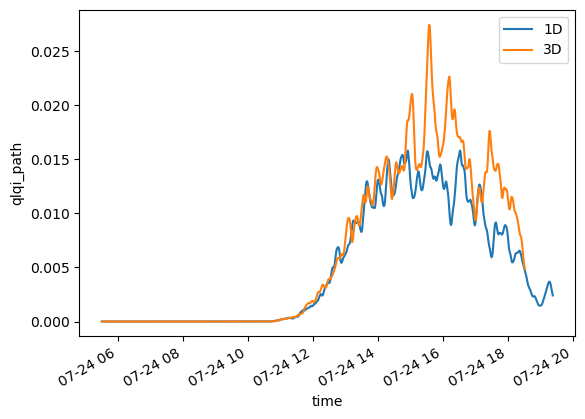

In [4]:
plot_domain_mean(ds_xy, var="qlqi_path", ds_xy2=ds_xy_rt, label="1D", label2="3D")

In [ ]:
ds_xy_rt['sw_flux_dn_rt'] = ds_xy_rt.sw_flux_sfc_dif_rt + ds_xy_rt.sw_flux_sfc_dir_rt

plot_cross_sections(ds_rt, ds_xy_rt, time = TIME_VAL, yidx=half_idx, xidx=half_idx, qv_vmin = 0.008, zmax=3500, flux_var_name = 'sw_flux_dn_rt')
plot_flux_sections(ds_rt, ds_xy_rt, time = TIME_VAL, yidx=half_idx, xidx=half_idx)

In [ ]:
ds_xy['cc'] = ds_xy['qlqi_path'] > 0
ds_xy_rt['cc'] = ds_xy_rt['qlqi_path'] > 0

plot_domain_mean(ds_xy, var="cc", ds_xy2=ds_xy_rt, label="1D", label2="3D")
plot_domain_mean(ds_xy, var="b", ds_xy2=ds_xy_rt, label="1D", label2="3D")
plot_domain_mean(ds_xy, var="sw_flux_dn", ds_xy2=ds_xy_rt, label="1D", label2="3D")
plot_domain_mean(ds_xy, var="qlqi_top", ds_xy2=ds_xy_rt, label="1D", label2="3D")
plot_domain_mean(ds_xy, var="thl_fluxbot", ds_xy2=ds_xy_rt, label="1D", label2="3D")

In [ ]:
plot_domain_mean(ds_xy, var="qlqi_base", ds_xy2=ds_xy_rt, label="1D", label2="3D")

In [ ]:
fig, axs = plt.subplots(2, 3, figsize = (16, 10))

ds_xy.sw_flux_dn.sel(time=TIME_VAL).plot(ax = axs[0][0])
((ds_xy.qlqi_path > 0).astype(float)).sel(time=TIME_VAL).plot.contour(ax = axs[0][0],
    levels=[0.5], colors="black", linewidths=1.5
)
axs[0][0].set_title("")
(ds_xy.thl_fluxbot.sel(time=TIME_VAL)).plot(ax = axs[0][1])
((ds_xy.qlqi_path > 0).astype(float)).sel(time=TIME_VAL).plot.contour(ax = axs[0][1],
    levels=[0.5], colors="black", linewidths=1.5
)
axs[0][1].set_title("1D")

ds_xy.qt_fluxbot.sel(time=TIME_VAL).plot(ax = axs[0][2])
((ds_xy.qlqi_path > 0).astype(float)).sel(time=TIME_VAL).plot.contour(ax = axs[0][2],
    levels=[0.5], colors="black", linewidths=1.5
)
axs[0][2].set_title("")



ds_xy_rt.sw_flux_dn_rt.sel(time=TIME_VAL).plot(ax = axs[1][0])
((ds_xy_rt.qlqi_path > 0).astype(float)).sel(time=TIME_VAL).plot.contour(ax = axs[1][0],
    levels=[0.5], colors="black", linewidths=1.5
)
axs[1][0].set_title("")
(ds_xy_rt.thl_fluxbot.sel(time=TIME_VAL)).plot(ax = axs[1][1])
((ds_xy_rt.qlqi_path > 0).astype(float)).sel(time=TIME_VAL).plot.contour(ax = axs[1][1],
    levels=[0.5], colors="black", linewidths=1.5
)
axs[1][1].set_title("3D")
ds_xy_rt.qt_fluxbot.sel(time=TIME_VAL).plot(ax = axs[1][2])
((ds_xy_rt.qlqi_path > 0).astype(float)).sel(time=TIME_VAL).plot.contour(ax = axs[1][2],
    levels=[0.5], colors="black", linewidths=1.5
)
axs[1][2].set_title("")

plt.tight_layout()
plt.show()

In [ ]:
da_diff = (ds_xy_rt.qlqi_path.mean(['x', 'y']) - ds_xy.isel(time = slice(None, 783)).qlqi_path.mean(['x', 'y']))

In [ ]:
da_diff = da_diff.load()

In [ ]:
fig, ax = plt.subplots(figsize = (10, 5))
(da_diff.rolling(time=60, center=True).mean()*1000).plot(ax = ax)
plt.tight_layout()

In [34]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

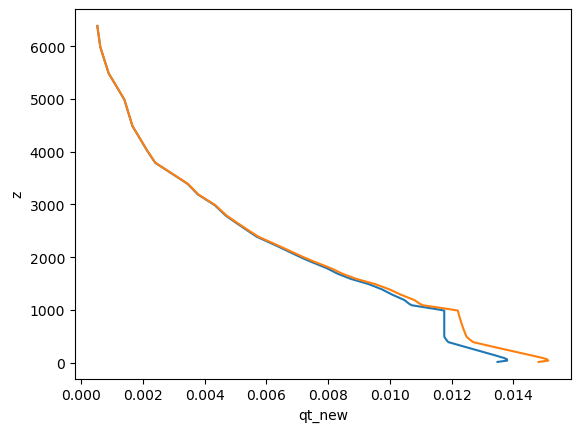

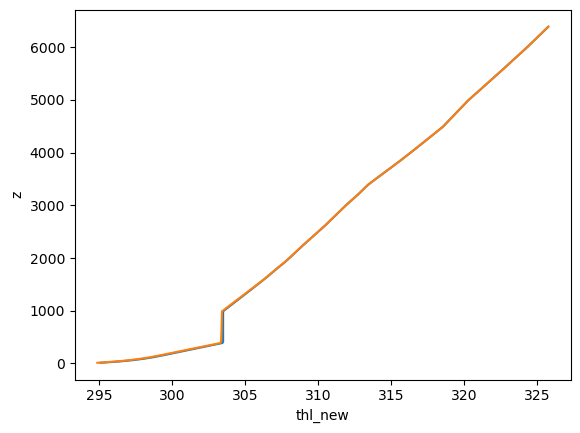

In [49]:
ds_in = xr.open_dataset('/pscratch/sd/m/mpowell/CASS_LES_2stream/cass_input.nc', group = 'init')

alpha = 0.1
H_q = 1000
ds_in['qt_new'] = (ds_in.qt * (1 + alpha * np.exp(-ds_in.z/H_q)))

ds_in['thv'] = ds_in.thl * (1 + 0.6*ds_in.qt)
ds_in['thl_new'] = ds_in['thv']/(1 + 0.6*ds_in.qt_new)

ds_in.qt.plot(y = 'z')
ds_in.qt_new.plot(y = 'z')
plt.show()

ds_in.thl.plot(y = 'z')
ds_in.thl_new.plot(y = 'z')
plt.show()

# θv = θ · (1 + 0.61q)
# q(z) = q_ref(z) · (1 + α · exp(-z/H_q))

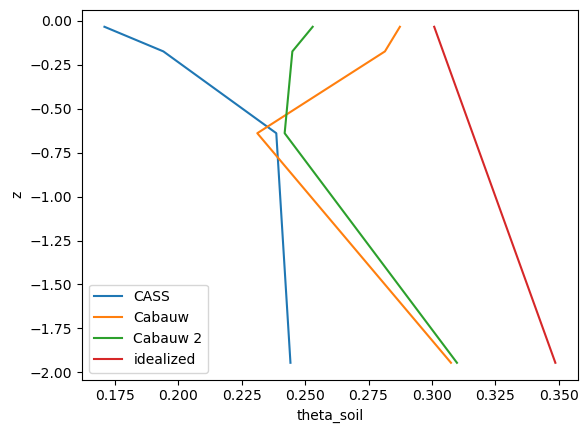

In [33]:
ds_in = xr.open_dataset('/pscratch/sd/m/mpowell/CASS_LES_2stream/cass_input.nc', group = 'soil')

ds_in_cabauw = xr.open_dataset('/pscratch/sd/m/mpowell/inputfiles_cumulus_cases_2/20140716_t03/cabauw_input.nc', group = 'soil')
ds_in_cabauw2 = xr.open_dataset('/pscratch/sd/m/mpowell/inputfiles_cumulus_cases_2/20160815_t03/cabauw_input.nc', group = 'soil')

ds_in.theta_soil.plot(y = 'z', label = "CASS")
ds_in_cabauw.theta_soil.plot(y = 'z', label = "Cabauw")
ds_in_cabauw2.theta_soil.plot(y = 'z', label = "Cabauw 2")

plt.plot(0.3 + ds_in.z*(-0.025), ds_in.z, label = 'idealized')
plt.legend()

In [1]:
import xarray as xr

In [2]:
ds = xr.open_dataset("/global/homes/m/mpowell/repos/microhh/cases/cass/shcu_sgp_summer_97to09.nc")

In [3]:
ds

<xarray.Dataset> Size: 161kB
Dimensions:  (year: 13, mon: 4, day: 31, hour: 24)
Coordinates:
  * year     (year) float32 52B 1.997e+03 1.998e+03 ... 2.008e+03 2.009e+03
  * mon      (mon) float32 16B 5.0 6.0 7.0 8.0
  * day      (day) float32 124B 1.0 2.0 3.0 4.0 5.0 ... 27.0 28.0 29.0 30.0 31.0
  * hour     (hour) float32 96B 0.5 1.5 2.5 3.5 4.5 ... 19.5 20.5 21.5 22.5 23.5
Data variables:
    shcu     (year, mon, day, hour) float32 155kB ...
    dscu     (year, mon, day) float32 6kB ...
Attributes:
    Comments:   Summertime cases: May to August in year 1997-2009.  Shcu inde...
    Source:     new.ncl
    Author:     Yunyan Zhang
    date:       Wed Sep  2 13:33:14 PDT 2015
    comments2:  checked again for Laura Riihimaki's project on developing aut...